# Global Calibration Sweep Analysis

This notebook analyzes outputs from `calibration/scripts/sweep_global_calibration.ps1` and visualizes:

- protocol-level results from `protocol_summary.json` and `protocol_report.json`
- parameter influence and pass/fail patterns
- measured transfer curves vs manual-derived reference curves (`calibration/reference/transfer_curve_ref_*.csv`)

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'CMakeLists.txt').exists():
            return p
    return start

repo_root = find_repo_root(Path.cwd())
candidates = [
    repo_root / 'calibration' / 'outputs' / 'calibration_sweep',
    repo_root / 'tmp' / 'calibration_sweep',
    repo_root / 'tmp' / 'calibration' / 'sweep',
]

sweep_root = next((p for p in candidates if p.exists()), None)
if sweep_root is None:
    raise FileNotFoundError(f'Could not find sweep folder. Tried: {candidates}')

calibration_root = repo_root / 'calibration'
reference_dir = calibration_root / 'reference'
notebooks_dir = calibration_root / 'notebooks'
tests_dir = repo_root / 'tests'

print(f'repo_root: {repo_root}')
print(f'sweep_root: {sweep_root}')
print(f'reference_dir: {reference_dir}')
print(f'notebooks_dir: {notebooks_dir}')

repo_root: d:\dev\projects\phu-fair-kid-67
sweep_root: d:\dev\projects\phu-fair-kid-67\calibration\outputs\calibration_sweep
reference_dir: d:\dev\projects\phu-fair-kid-67\calibration\reference
notebooks_dir: d:\dev\projects\phu-fair-kid-67\calibration\notebooks


In [3]:
protocol_summary_path = sweep_root / 'protocol_summary.json'
protocol_report_path = sweep_root / 'protocol_report.json'
sweep_results_path = sweep_root / 'sweep_results.json'

for p in [protocol_summary_path, protocol_report_path, sweep_results_path]:
    if not p.exists():
        raise FileNotFoundError(p)

protocol_summary = json.loads(protocol_summary_path.read_text(encoding='utf-8'))
protocol_report = json.loads(protocol_report_path.read_text(encoding='utf-8'))
sweep_results = json.loads(sweep_results_path.read_text(encoding='utf-8'))

summary_df = pd.DataFrame(protocol_summary.get('passingCandidates', []))
report_summary = protocol_report.get('summary', {})

print('Generated:', protocol_summary.get('generatedAt'))
print('Protocol summary (report):', report_summary)
print('passingCandidates rows:', len(summary_df))
print('sweep_results rows:', len(sweep_results))

Generated: 2026-05-14T00:29:24.332413+00:00
Protocol summary (report): {'totalParamSets': 161, 'passingParamSets': 21, 'identifiabilityPass': True, 'cvMaxSweepLikelyInactive': False}
passingCandidates rows: 21
sweep_results rows: 161


In [4]:
best = protocol_summary.get('bestPassing') or protocol_report.get('bestCandidate', {})
display(pd.Series(best, name='best_candidate'))

if not summary_df.empty:
    cols = [c for c in ['gain', 'knee', 'cvMax', 'protocolScore', 'weightedScore', 'totalScore'] if c in summary_df.columns]
    display(summary_df.sort_values('protocolScore', ascending=True)[cols].head(20))

gain                                                           0.6
knee                                                          0.75
cvMax                                                          9.0
protocolScore                                             5.372537
cvUtilization    {'meanClampRatio': 0.0, 'maxClampRatio': 0.0, ...
familyDeltas     {'cp1': {'thresh3v5_minus_thresh10v0': -0.0622...
Name: best_candidate, dtype: object

,gain,knee,cvMax,protocolScore,weightedScore,totalScore
0,0.6,0.75,9.0,5.372537,5.29455,4.713
1,0.6,0.50,9.0,5.422537,5.29455,4.713
2,0.6,1.00,9.0,5.422537,5.29455,4.713
3,0.6,0.75,10.0,5.472537,5.29455,4.713
4,0.6,0.75,8.0,5.472537,5.29455,4.713
5,0.6,1.25,9.0,5.472537,5.29455,4.713
6,0.6,0.50,10.0,5.522537,5.29455,4.713
7,0.6,0.50,8.0,5.522537,5.29455,4.713
8,0.6,1.50,9.0,5.522537,5.29455,4.713
9,0.6,1.00,8.0,5.522537,5.29455,4.713


In [5]:
all_df = pd.DataFrame(sweep_results)
numeric_cols = ['gain', 'knee', 'cvMax', 'protocolScore', 'weightedScore', 'totalScore']
for c in numeric_cols:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

if 'hardPass' not in all_df.columns:
    all_df['hardPass'] = all_df.get('hardFailures', []).apply(lambda x: isinstance(x, list) and len(x) == 0)

display(all_df[['gain', 'knee', 'cvMax', 'protocolScore', 'hardPass']].head())

,gain,knee,cvMax,protocolScore,hardPass
0,0.6,0.75,9.0,5.372537,True
1,0.6,0.50,9.0,5.422537,True
2,0.6,1.00,9.0,5.422537,True
3,0.6,0.75,10.0,5.472537,True
4,0.6,0.75,8.0,5.472537,True


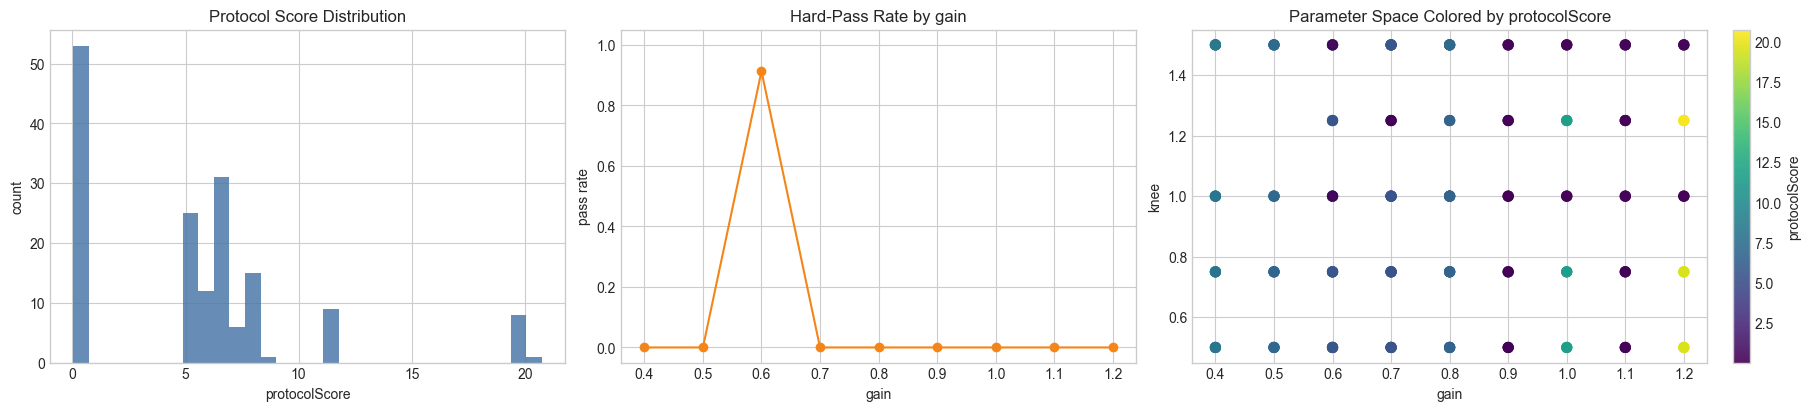

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].hist(all_df['protocolScore'].dropna(), bins=30, color='#4C78A8', alpha=0.85)
axes[0].set_title('Protocol Score Distribution')
axes[0].set_xlabel('protocolScore')
axes[0].set_ylabel('count')

hp = all_df.copy()
hp['hardPassInt'] = hp['hardPass'].astype(int)
pass_rate_gain = hp.groupby('gain', as_index=False)['hardPassInt'].mean()
axes[1].plot(pass_rate_gain['gain'], pass_rate_gain['hardPassInt'], marker='o', color='#F58518')
axes[1].set_title('Hard-Pass Rate by gain')
axes[1].set_xlabel('gain')
axes[1].set_ylabel('pass rate')
axes[1].set_ylim(-0.05, 1.05)

sc = axes[2].scatter(
    all_df['gain'],
    all_df['knee'],
    c=all_df['protocolScore'],
    cmap='viridis',
    s=50,
    alpha=0.9
)
axes[2].set_title('Parameter Space Colored by protocolScore')
axes[2].set_xlabel('gain')
axes[2].set_ylabel('knee')
fig.colorbar(sc, ax=axes[2], label='protocolScore')

plt.show()

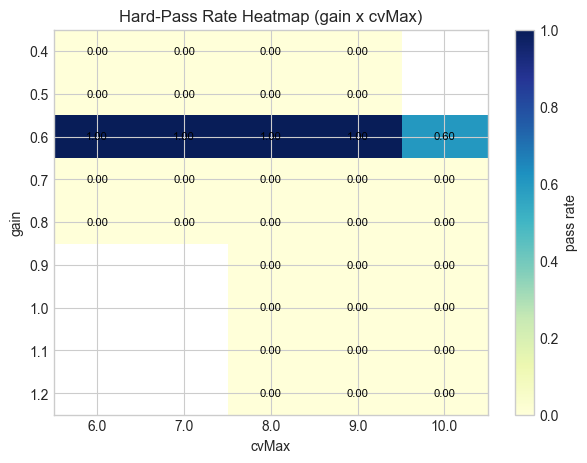

In [7]:
def pivot_pass_rate(df: pd.DataFrame, index_col: str, col_col: str) -> pd.DataFrame:
    tmp = df.copy()
    tmp['hardPassInt'] = tmp['hardPass'].astype(int)
    return tmp.pivot_table(index=index_col, columns=col_col, values='hardPassInt', aggfunc='mean').sort_index()

heat = pivot_pass_rate(all_df, 'gain', 'cvMax')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels([str(x) for x in heat.columns])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels([str(x) for x in heat.index])
ax.set_xlabel('cvMax')
ax.set_ylabel('gain')
ax.set_title('Hard-Pass Rate Heatmap (gain x cvMax)')

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, label='pass rate')
plt.show()

In [8]:
curve_order = ['thresh10v0', 'thresh3v5', 'thresh2v8', 'thresh2v0', 'thresh0v0']
curve_colors = {
    'thresh10v0': '#4C78A8',
    'thresh3v5': '#F58518',
    'thresh2v8': '#54A24B',
    'thresh2v0': '#E45756',
    'thresh0v0': '#B279A2',
}

def format_param_dir(gain: float, knee: float, cv_max: float) -> str:
    def fmt(v: float) -> str:
        s = f'{v:.6g}'
        return s.rstrip('0').rstrip('.') if '.' in s else s
    return f'gain_{fmt(gain)}_knee_{fmt(knee)}_cvMax_{fmt(cv_max)}'

def parse_threshold_from_name(name: str) -> float:
    m = re.match(r'^thresh(\d+)v(\d+)$', name)
    if not m:
        raise ValueError(f'Unexpected threshold name: {name}')
    return float(f'{m.group(1)}.{m.group(2)}')

def load_curve_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, comment='#')

def load_curve_family(folder: Path) -> dict:
    out = {}
    for curve in curve_order:
        p = folder / f'{curve}.csv'
        if p.exists():
            out[curve] = load_curve_csv(p)
    return out

manual_refs = {}
reference_candidates = [reference_dir, tests_dir]
for curve in curve_order:
    rp = None
    for base in reference_candidates:
        candidate = base / f'transfer_curve_ref_{curve}.csv'
        if candidate.exists():
            rp = candidate
            break
    if rp is not None:
        manual_refs[curve] = load_curve_csv(rp)

print('Loaded manual reference curves:', sorted(manual_refs.keys()))

Loaded manual reference curves: ['thresh0v0', 'thresh10v0', 'thresh2v0', 'thresh2v8', 'thresh3v5']


In [9]:
best_gain = float(best.get('gain'))
best_knee = float(best.get('knee'))
best_cv = float(best.get('cvMax'))

best_dir_name = format_param_dir(best_gain, best_knee, best_cv)
best_dir = sweep_root / best_dir_name
if not best_dir.exists():
    raise FileNotFoundError(f'Best folder not found: {best_dir}')

best_curves = load_curve_family(best_dir)
print('Best candidate dir:', best_dir)
print('Curve files loaded:', sorted(best_curves.keys()))

Best candidate dir: d:\dev\projects\phu-fair-kid-67\calibration\outputs\calibration_sweep\gain_0.6_knee_0.75_cvMax_9
Curve files loaded: ['thresh0v0', 'thresh10v0', 'thresh2v0', 'thresh2v8', 'thresh3v5']


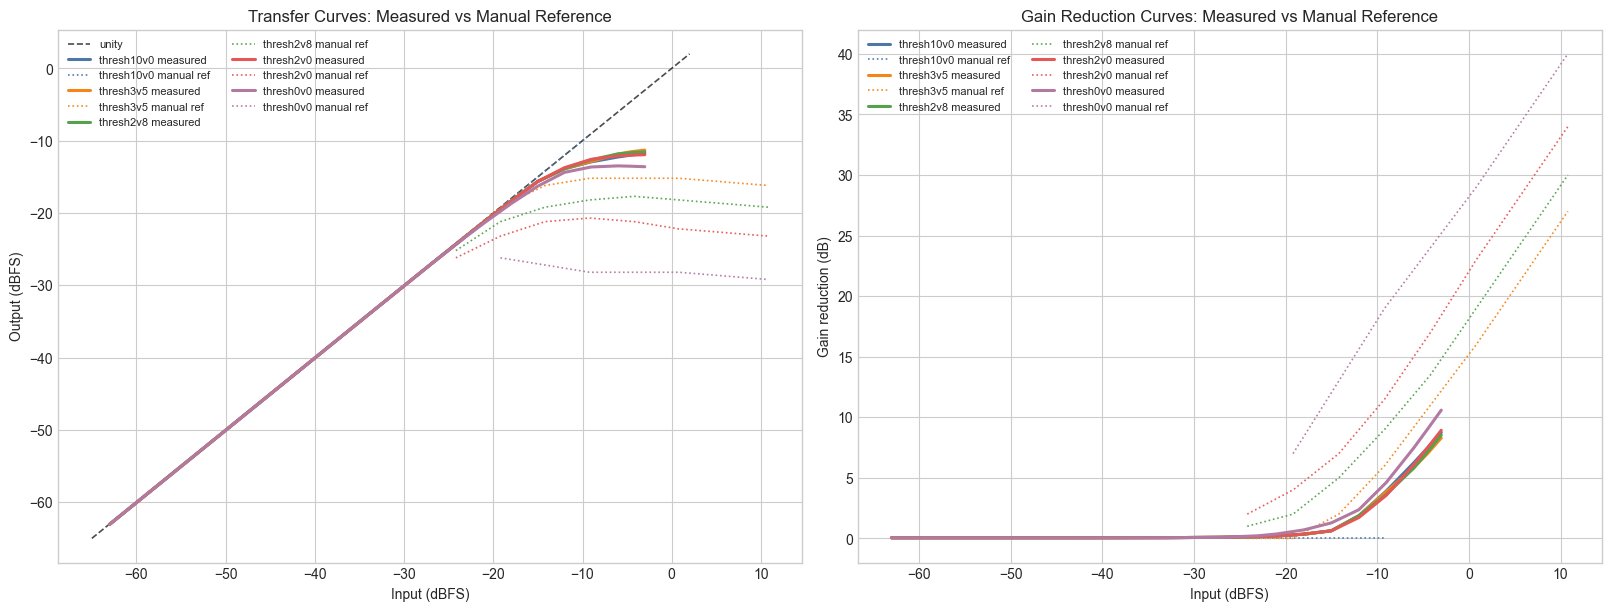

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Left: input vs output
x_line = np.linspace(-65, 2, 200)
axes[0].plot(x_line, x_line, 'k--', lw=1.2, alpha=0.7, label='unity')

for curve in curve_order:
    if curve not in best_curves:
        continue
    df = best_curves[curve]
    c = curve_colors.get(curve, None)
    axes[0].plot(df['input_dbfs'], df['output_dbfs'], color=c, lw=2.2, label=f'{curve} measured')

    if curve in manual_refs:
        ref = manual_refs[curve]
        axes[0].plot(ref['input_dbfs'], ref['output_dbfs'], color=c, lw=1.2, ls=':', alpha=0.95, label=f'{curve} manual ref')

axes[0].set_title('Transfer Curves: Measured vs Manual Reference')
axes[0].set_xlabel('Input (dBFS)')
axes[0].set_ylabel('Output (dBFS)')
axes[0].legend(fontsize=8, ncol=2)

# Right: gain reduction
for curve in curve_order:
    if curve not in best_curves:
        continue
    df = best_curves[curve]
    c = curve_colors.get(curve, None)
    axes[1].plot(df['input_dbfs'], df['gain_reduction_db'], color=c, lw=2.2, label=f'{curve} measured')

    if curve in manual_refs:
        ref = manual_refs[curve]
        axes[1].plot(ref['input_dbfs'], ref['gain_reduction_db'], color=c, lw=1.2, ls=':', alpha=0.95, label=f'{curve} manual ref')

axes[1].set_title('Gain Reduction Curves: Measured vs Manual Reference')
axes[1].set_xlabel('Input (dBFS)')
axes[1].set_ylabel('Gain reduction (dB)')
axes[1].legend(fontsize=8, ncol=2)

plt.show()

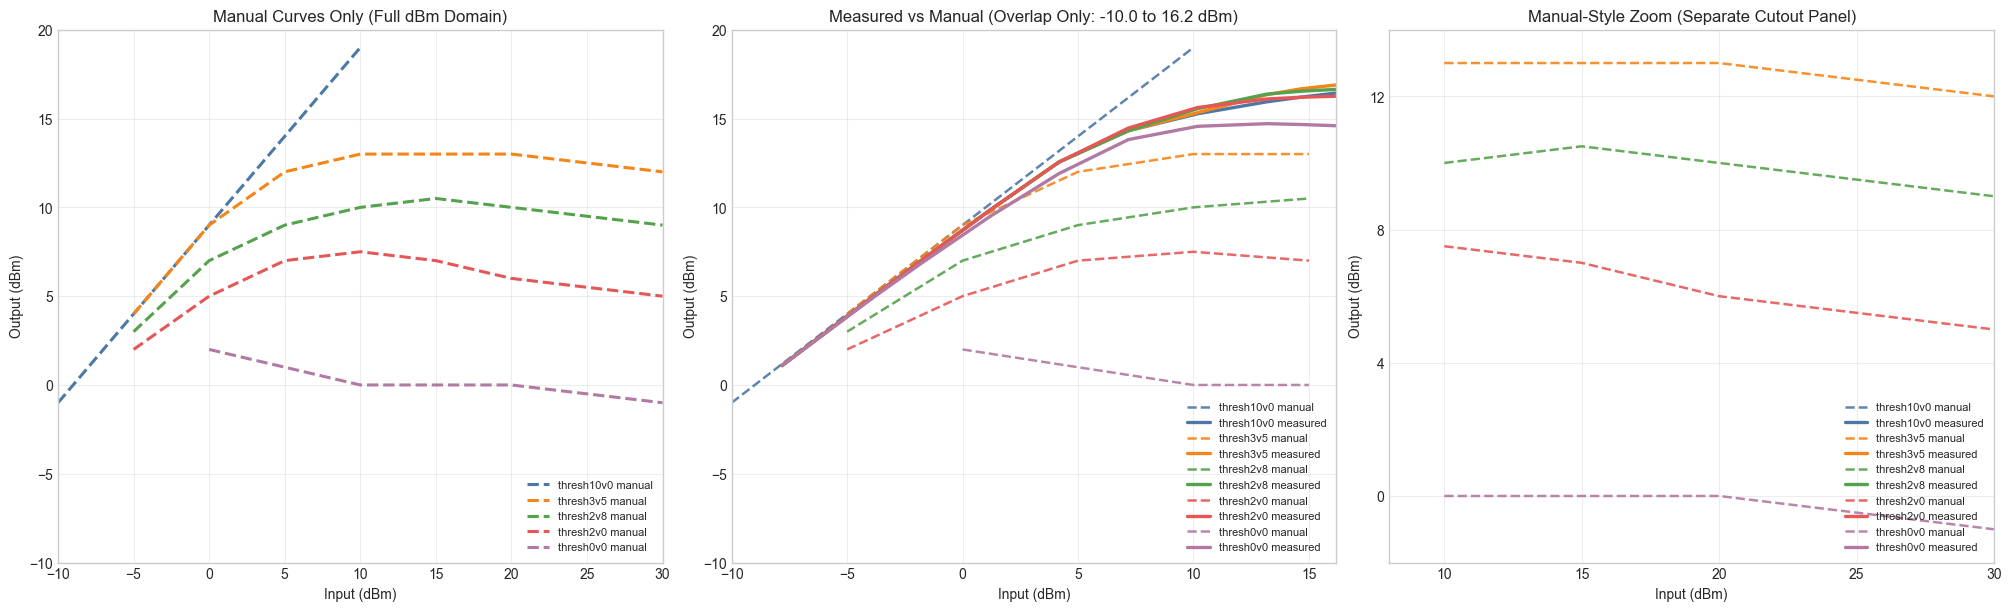

In [11]:
DBFS_TO_DBM = 19.2
OUTPUT_GAIN_ALIGN_DB = 9.0

def _manual_curve_dbm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'input_dbm' not in out.columns:
        out['input_dbm'] = out['input_dbfs'] + DBFS_TO_DBM
    if 'output_dbm' not in out.columns:
        out['output_dbm'] = out['output_dbfs'] + DBFS_TO_DBM + OUTPUT_GAIN_ALIGN_DB
    return out

def _measured_curve_dbm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['input_dbm'] = out['input_dbfs'] + DBFS_TO_DBM
    out['output_dbm'] = out['output_dbfs'] + DBFS_TO_DBM + OUTPUT_GAIN_ALIGN_DB
    return out

meas_dbm = {}
ref_dbm = {}
for curve in curve_order:
    if curve in best_curves:
        meas_dbm[curve] = _measured_curve_dbm(best_curves[curve])
    if curve in manual_refs:
        ref_dbm[curve] = _manual_curve_dbm(manual_refs[curve])

measured_max_dbm = np.nanmax([
    d['input_dbm'].max() for d in meas_dbm.values() if 'input_dbm' in d.columns and len(d) > 0
])
overlap_xmin = -10.0
overlap_xmax = float(measured_max_dbm)

zoom_xmin, zoom_xmax = 8.0, 30.0
zoom_ymin, zoom_ymax = -2.0, 14.0

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

# Panel A: manual-only full domain
ax = axes[0]
for curve in curve_order:
    if curve not in ref_dbm:
        continue
    c = curve_colors.get(curve, None)
    ref = ref_dbm[curve]
    ax.plot(ref['input_dbm'], ref['output_dbm'], color=c, lw=2.2, ls='--', label=f'{curve} manual')
ax.set_xlim(-10, 30)
ax.set_ylim(-10, 20)
ax.set_xlabel('Input (dBm)')
ax.set_ylabel('Output (dBm)')
ax.set_title('Manual Curves Only (Full dBm Domain)')
ax.grid(True, alpha=0.35)
ax.legend(fontsize=8, ncol=1, loc='lower right')

# Panel B: overlap-only measured vs manual
ax = axes[1]
for curve in curve_order:
    c = curve_colors.get(curve, None)
    if curve in ref_dbm:
        ref = ref_dbm[curve]
        ref_overlap = ref[(ref['input_dbm'] >= overlap_xmin) & (ref['input_dbm'] <= overlap_xmax)]
        ax.plot(ref_overlap['input_dbm'], ref_overlap['output_dbm'], color=c, lw=1.8, ls='--', alpha=0.9, label=f'{curve} manual')
    if curve in meas_dbm:
        meas = meas_dbm[curve]
        meas_overlap = meas[(meas['input_dbm'] >= overlap_xmin) & (meas['input_dbm'] <= overlap_xmax)]
        ax.plot(meas_overlap['input_dbm'], meas_overlap['output_dbm'], color=c, lw=2.4, label=f'{curve} measured')
ax.set_xlim(overlap_xmin, overlap_xmax)
ax.set_ylim(-10, 20)
ax.set_xlabel('Input (dBm)')
ax.set_ylabel('Output (dBm)')
ax.set_title(f'Measured vs Manual (Overlap Only: {overlap_xmin:.1f} to {overlap_xmax:.1f} dBm)')
ax.grid(True, alpha=0.35)
ax.legend(fontsize=8, ncol=1, loc='lower right')

# Panel C: manual-style zoom as separate panel
ax = axes[2]
for curve in curve_order:
    c = curve_colors.get(curve, None)
    if curve in ref_dbm:
        ref = ref_dbm[curve]
        ref_zoom = ref[(ref['input_dbm'] >= zoom_xmin) & (ref['input_dbm'] <= zoom_xmax)]
        ax.plot(ref_zoom['input_dbm'], ref_zoom['output_dbm'], color=c, lw=1.8, ls='--', alpha=0.9, label=f'{curve} manual')
    if curve in meas_dbm:
        meas = meas_dbm[curve]
        meas_zoom = meas[(meas['input_dbm'] >= zoom_xmin) & (meas['input_dbm'] <= zoom_xmax)]
        ax.plot(meas_zoom['input_dbm'], meas_zoom['output_dbm'], color=c, lw=2.4, label=f'{curve} measured')
ax.set_xlim(zoom_xmin, zoom_xmax)
ax.set_ylim(zoom_ymin, zoom_ymax)
ax.set_xticks([10, 15, 20, 25, 30])
ax.set_yticks([0, 4, 8, 12])
ax.set_xlabel('Input (dBm)')
ax.set_ylabel('Output (dBm)')
ax.set_title('Manual-Style Zoom (Separate Cutout Panel)')
ax.grid(True, alpha=0.35)
ax.legend(fontsize=8, ncol=1, loc='lower right')

plt.show()

In [12]:
def curve_error_table(measured: dict, reference: dict, key: str) -> pd.DataFrame:
    rows = []
    for curve in curve_order:
        if curve not in measured or curve not in reference:
            continue

        m = measured[curve][['input_dbfs', key]].copy().rename(columns={key: 'measured'})
        r = reference[curve][['input_dbfs', key]].copy().rename(columns={key: 'reference'})
        merged = pd.merge(m, r, on='input_dbfs', how='inner')
        merged['abs_err'] = (merged['measured'] - merged['reference']).abs()

        rows.append({
            'curve': curve,
            'metric': key,
            'mae': merged['abs_err'].mean(),
            'max_err': merged['abs_err'].max(),
            'n': len(merged),
        })

    return pd.DataFrame(rows).sort_values(['metric', 'mae'])

err_out = curve_error_table(best_curves, manual_refs, 'output_dbfs')
err_gr = curve_error_table(best_curves, manual_refs, 'gain_reduction_db')
display(err_out)
display(err_gr)

,curve,metric,mae,max_err,n
0,thresh10v0,output_dbfs,NaN,NaN,0
1,thresh3v5,output_dbfs,NaN,NaN,0
2,thresh2v8,output_dbfs,NaN,NaN,0
3,thresh2v0,output_dbfs,NaN,NaN,0
4,thresh0v0,output_dbfs,NaN,NaN,0


,curve,metric,mae,max_err,n
0,thresh10v0,gain_reduction_db,NaN,NaN,0
1,thresh3v5,gain_reduction_db,NaN,NaN,0
2,thresh2v8,gain_reduction_db,NaN,NaN,0
3,thresh2v0,gain_reduction_db,NaN,NaN,0
4,thresh0v0,gain_reduction_db,NaN,NaN,0


,delta,cp1 (-9.0 dBFS),cp2 (-6.0 dBFS)
0,thresh0v0_minus_thresh10v0,0.7055,1.2305
1,thresh0v0_minus_thresh2v0,1.0582,1.3896
2,thresh2v0_minus_thresh10v0,-0.3527,-0.1591
3,thresh2v0_minus_thresh3v5,-0.2905,0.2458
4,thresh2v8_minus_thresh10v0,-0.2880,-0.4334
5,thresh3v5_minus_thresh10v0,-0.0622,-0.4049


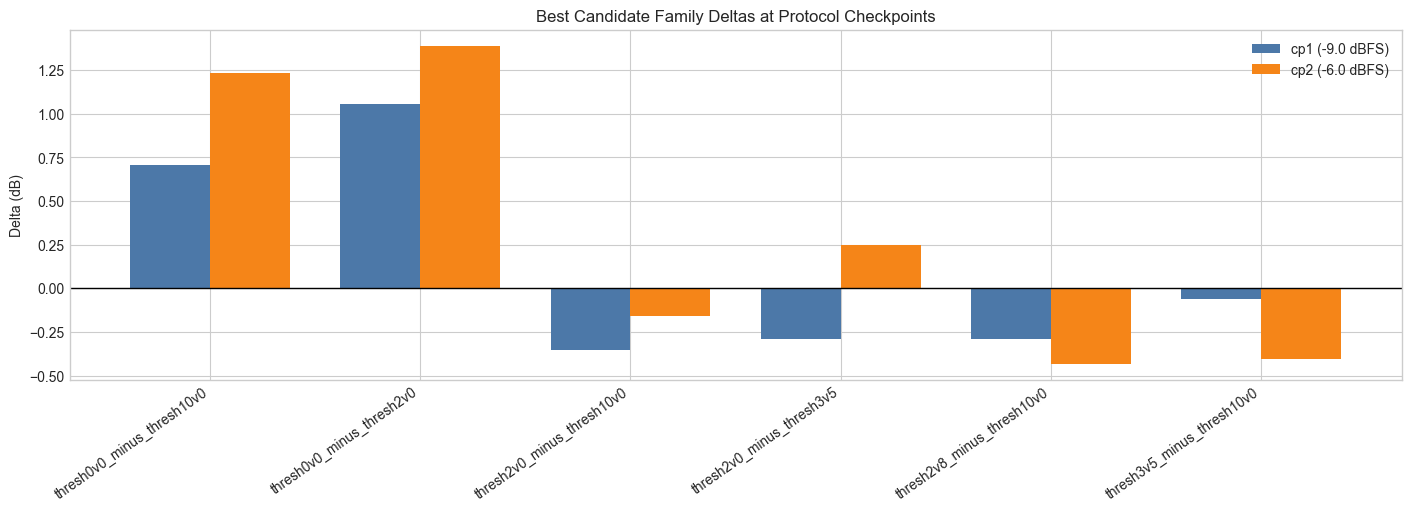

In [13]:
cp1 = protocol_summary.get('thresholds', {}).get('checkpoint1Db', -9.0)
cp2 = protocol_summary.get('thresholds', {}).get('checkpoint2Db', -6.0)
deltas = (protocol_summary.get('bestPassing') or {}).get('familyDeltas', {})

cp1d = deltas.get('cp1', {})
cp2d = deltas.get('cp2', {})
keys = sorted(set(cp1d.keys()) | set(cp2d.keys()))

bar_df = pd.DataFrame({
    'delta': keys,
    f'cp1 ({cp1} dBFS)': [cp1d.get(k, np.nan) for k in keys],
    f'cp2 ({cp2} dBFS)': [cp2d.get(k, np.nan) for k in keys],
})

display(bar_df)

x = np.arange(len(bar_df))
w = 0.38
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
ax.bar(x - w/2, bar_df[f'cp1 ({cp1} dBFS)'], width=w, label=f'cp1 ({cp1} dBFS)', color='#4C78A8')
ax.bar(x + w/2, bar_df[f'cp2 ({cp2} dBFS)'], width=w, label=f'cp2 ({cp2} dBFS)', color='#F58518')
ax.axhline(0.0, color='black', lw=1)
ax.set_title('Best Candidate Family Deltas at Protocol Checkpoints')
ax.set_ylabel('Delta (dB)')
ax.set_xticks(x)
ax.set_xticklabels(bar_df['delta'], rotation=35, ha='right')
ax.legend()
plt.show()

## Notes

- Manual-reference overlays use `calibration/reference/transfer_curve_ref_*.csv` (with fallback to `tests/` for compatibility).
- To compare a different candidate, set `best_gain`, `best_knee`, and `best_cv` manually in the candidate-selection cell.
- If you moved outputs, update `candidates` in the path-resolution cell.